# Exploratory Data Analysis

## Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import sys
from pathlib import Path
project_root = Path.cwd().parent 
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from src.utils import load_and_preprocess_data
# load data
file_path = '../Case_Study_Data_JNM.csv'
data, returns = load_and_preprocess_data(file_path)
returns.head()

,1,2,3,4,5
date,,,,,
2001-01-31,0.019259,0.007933,-0.025895,0.029028,0.013580
2001-02-28,-0.084626,0.011747,0.007353,-0.124214,-0.037645
2001-03-31,-0.065848,0.003618,-0.034438,-0.097128,-0.031738
2001-04-30,0.073714,-0.011915,0.021438,0.112584,0.030010
2001-05-31,-0.013033,0.003687,0.011842,-0.019486,-0.004708


<!-- ## 2. Plot Time Series -->

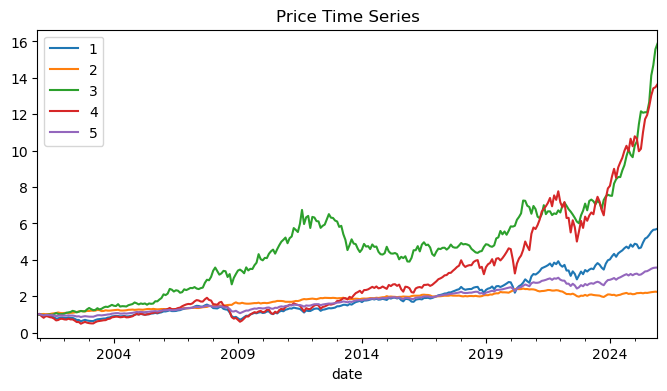

In [15]:
# plot time series of prices
data.plot(figsize=(8, 4), title='Price Time Series')
plt.show()

**Observations (Price Data):**
- **Different Trends:** Asset 3 and 4 exponential growth -> could be equities. 2 is stable -> could be fixed income instrument
- **Crisis Correlation:** simultaneous drawdowns during 2008 (Global Financial Crisis) and 2020 (COVID-19) -> tail dependence.
- periods of low vs. high trend (e.g., after 2023 acceleration for Asset 3)

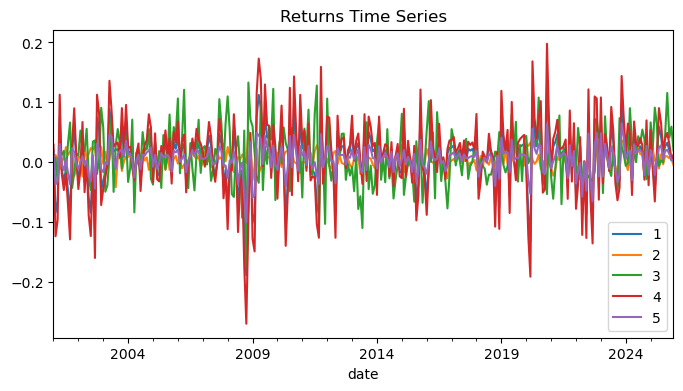

In [16]:
# plot time series of returns
returns.plot(figsize=(8, 4), title='Returns Time Series')
plt.show()

**Observations (Return Data):**
- **Heteroskedasticity:**  volatility clustering is visible (e.g., 2008, 2020) -> large changes follow large changes
- Asset 4: widest return spread (highest risk), Asset 2 is nearly flat (low risk)
- **Mean Reversion:** stable mean (near zero) -> stationarity

## Histograms and QQ-Plots

c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

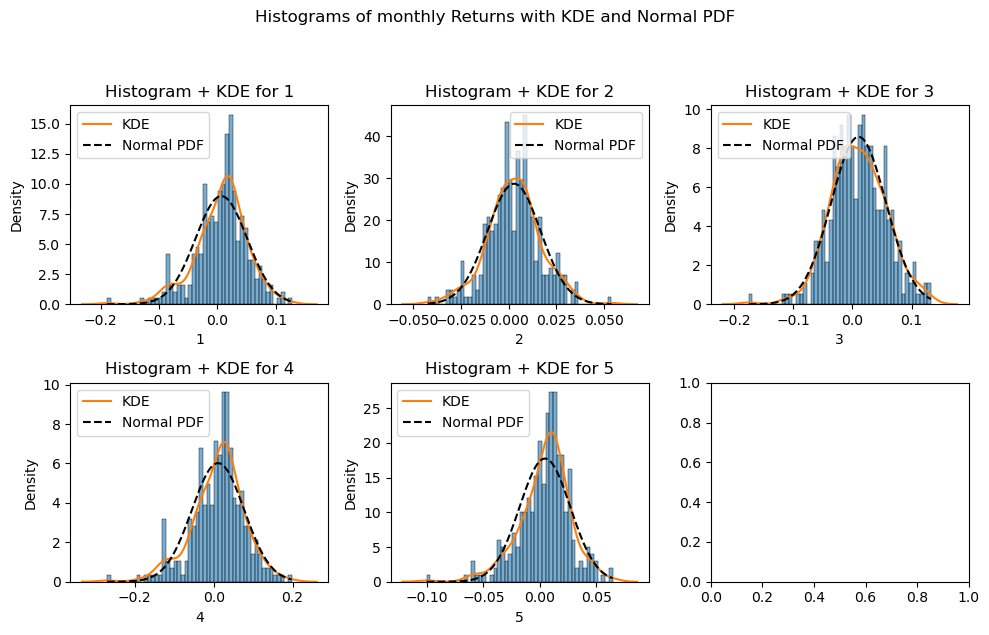

In [26]:
# plot histograms with KDE and normal pdf overlay
num_cols = returns.shape[1]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
if num_cols == 1:
    axes = [axes]
for ax, col in zip(axes.flatten(), returns.columns):
    sns.histplot(returns[col].dropna(), bins=50, kde=False, stat='density', ax=ax, color='C0', alpha=0.6)
    # KDE (redundant with kde=True but gives styling control)
    sns.kdeplot(returns[col].dropna(), ax=ax, color='C1', lw=1.5, label='KDE')
    # overlay fitted normal pdf for comparison
    x = np.linspace(returns[col].min(), returns[col].max(), 200)
    mu, std = returns[col].mean(), returns[col].std()
    ax.plot(x, stats.norm.pdf(x, mu, std), color='k', ls='--', label='Normal PDF')
    ax.set_title(f'Histogram + KDE for {col}')
    ax.legend()
plt.suptitle('Histograms of monthly Returns with KDE and Normal PDF', y=1.05)
plt.tight_layout()
plt.show()

c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

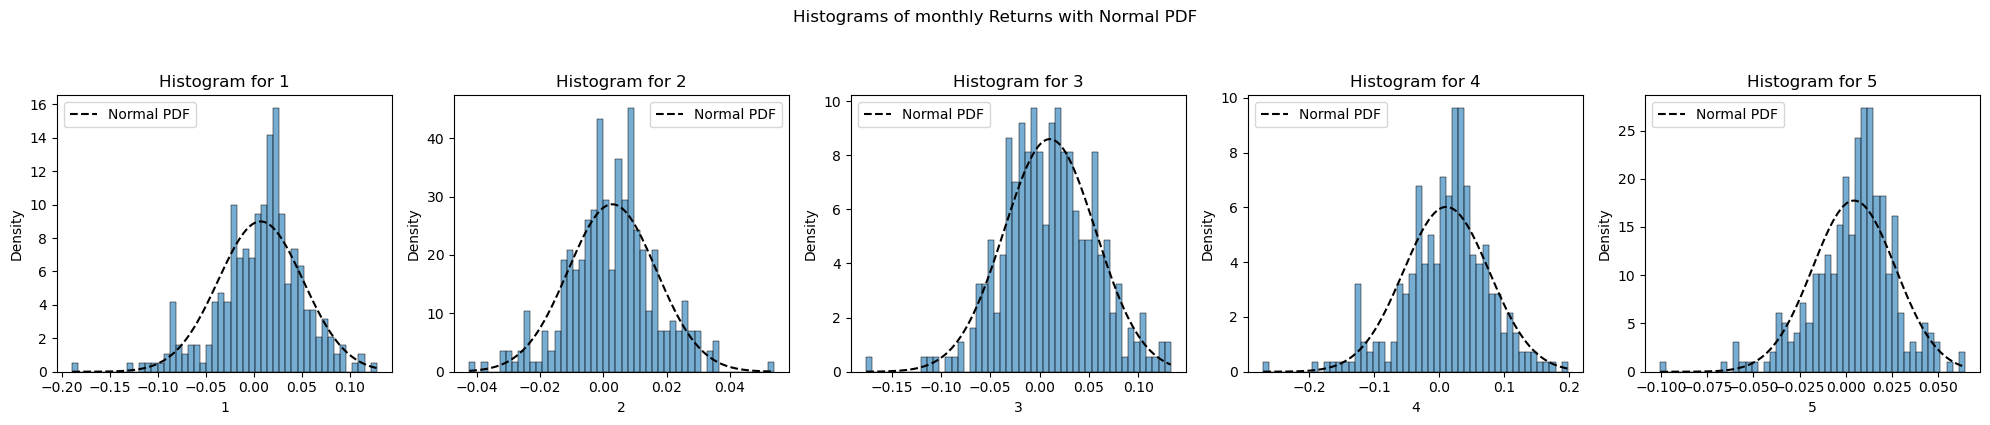

In [21]:
num_cols = returns.shape[1]
fig, axes = plt.subplots(1, num_cols, figsize=(4 * num_cols, 4))
if num_cols == 1:
    axes = [axes]
for ax, col in zip(axes, returns.columns):
    data_col = returns[col].dropna()
    sns.histplot(data_col, bins=50, kde=False, stat='density', ax=ax, color='C0', alpha=0.6)
    x = np.linspace(data_col.min(), data_col.max(), 200)
    mu, std = data_col.mean(), data_col.std()
    ax.plot(x, stats.norm.pdf(x, mu, std), color='k', ls='--', label='Normal PDF')
    ax.set_title(f'Histogram for {col}')
    ax.legend()
plt.suptitle('Histograms of monthly Returns with Normal PDF', y=1.05)
plt.tight_layout()
plt.show()

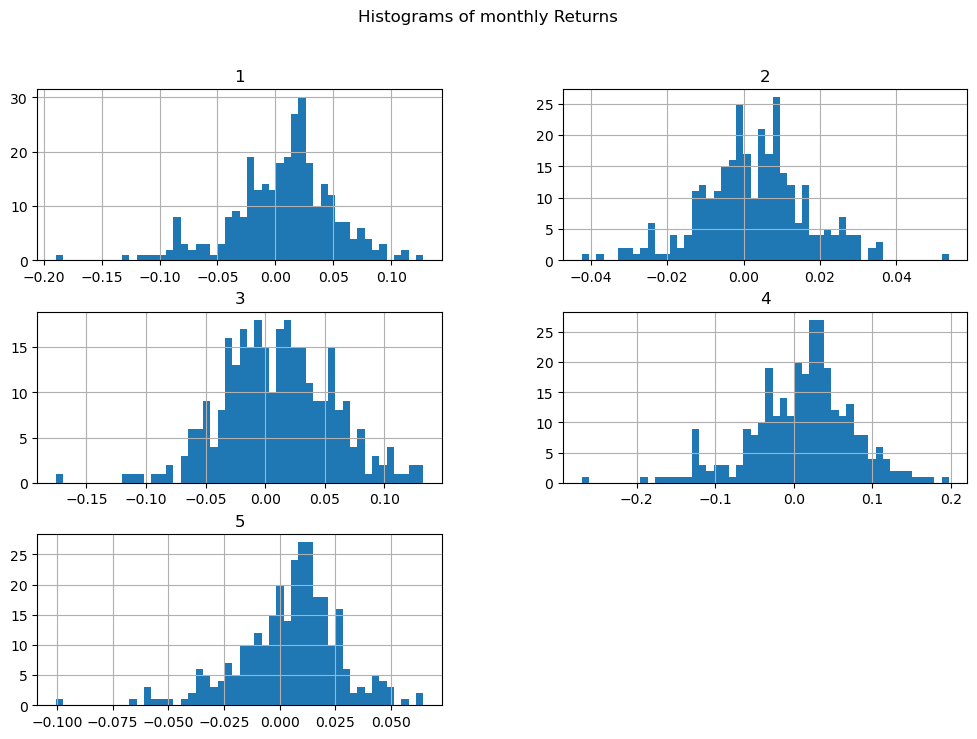

In [ ]:
# plot histograms
returns.hist(bins=50, figsize=(12, 8))
plt.suptitle('Histograms of monthly Returns')
plt.show()

**Observations (Distribution):**
- **Roughly normally distributed**
- **Fat Tails:** Extreme values (e.g., Asset 4 < -0.10) occur more frequently than a Normal distribution would predict -> heavy tails.
- **Peak at Mean:** High concentration of returns around zero (peakedness) compared to standard normal.
- **Skewness:** Slight negative skew visible in equity-like assets (longer left tails) -> crashes are more violent than rallies.

In [ ]:
# plot qq-plots
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, col in enumerate(returns.columns):
    stats.probplot(returns[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'QQ-Plot for {col}')
plt.tight_layout()
plt.show()

## 4. Summary Statistics

In [7]:
summary_stats = returns.describe().T
summary_stats

,count,mean,std,min,25%,50%,75%,max
1,300.0,0.006821,0.044370,-0.189602,-0.018438,0.013004,0.032098,0.127861
2,300.0,0.002785,0.013916,-0.042374,-0.005402,0.003137,0.010424,0.053775
3,300.0,0.010327,0.046413,-0.175604,-0.020672,0.010288,0.040633,0.132835
4,300.0,0.010986,0.066306,-0.270462,-0.027528,0.019569,0.048531,0.197797
5,300.0,0.004509,0.022492,-0.100435,-0.006921,0.007424,0.017627,0.064515


In [8]:
distribution_stats = summary_stats.copy()
distribution_stats['skew'] = returns.skew()
distribution_stats['kurt'] = returns.kurt()
distribution_stats['sem'] = returns.sem()
distribution_stats['var'] = returns.var()
distribution_stats = distribution_stats[['count','mean','std','var','min','max','skew','kurt']]
distribution_stats

,count,mean,std,var,min,max,skew,kurt
1,300.0,0.006821,0.044370,0.001969,-0.189602,0.127861,-0.634043,1.415463
2,300.0,0.002785,0.013916,0.000194,-0.042374,0.053775,-0.022974,0.735767
3,300.0,0.010327,0.046413,0.002154,-0.175604,0.132835,-0.066126,0.523666
4,300.0,0.010986,0.066306,0.004396,-0.270462,0.197797,-0.534254,1.202299
5,300.0,0.004509,0.022492,0.000506,-0.100435,0.064515,-0.693021,1.849615


## 5. Autocorrelation Analysis

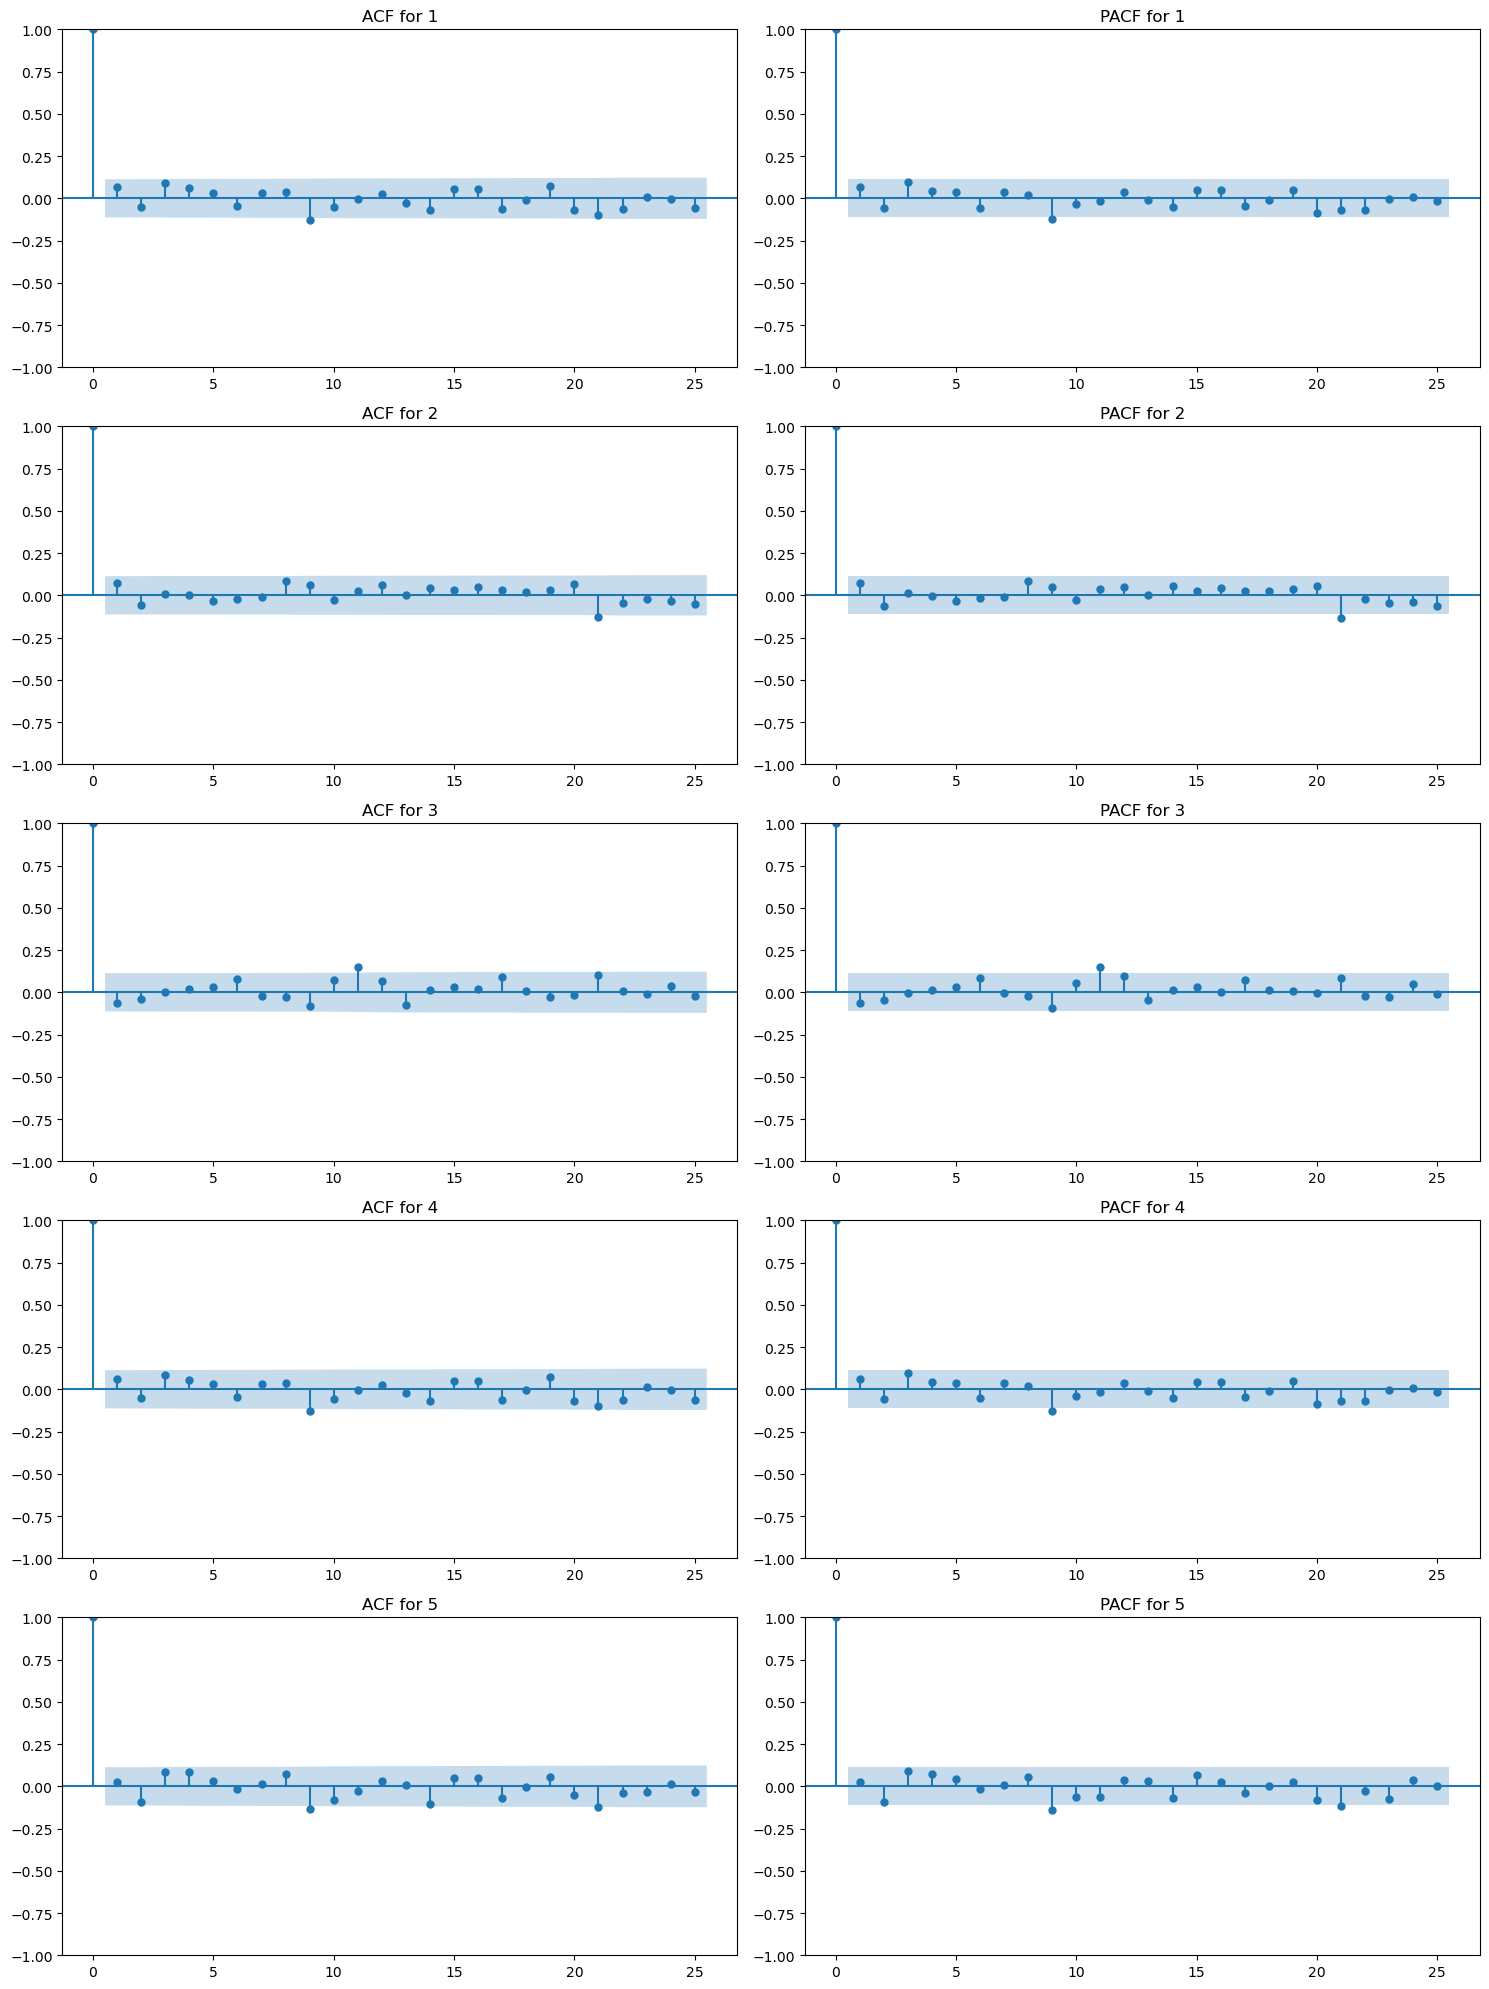

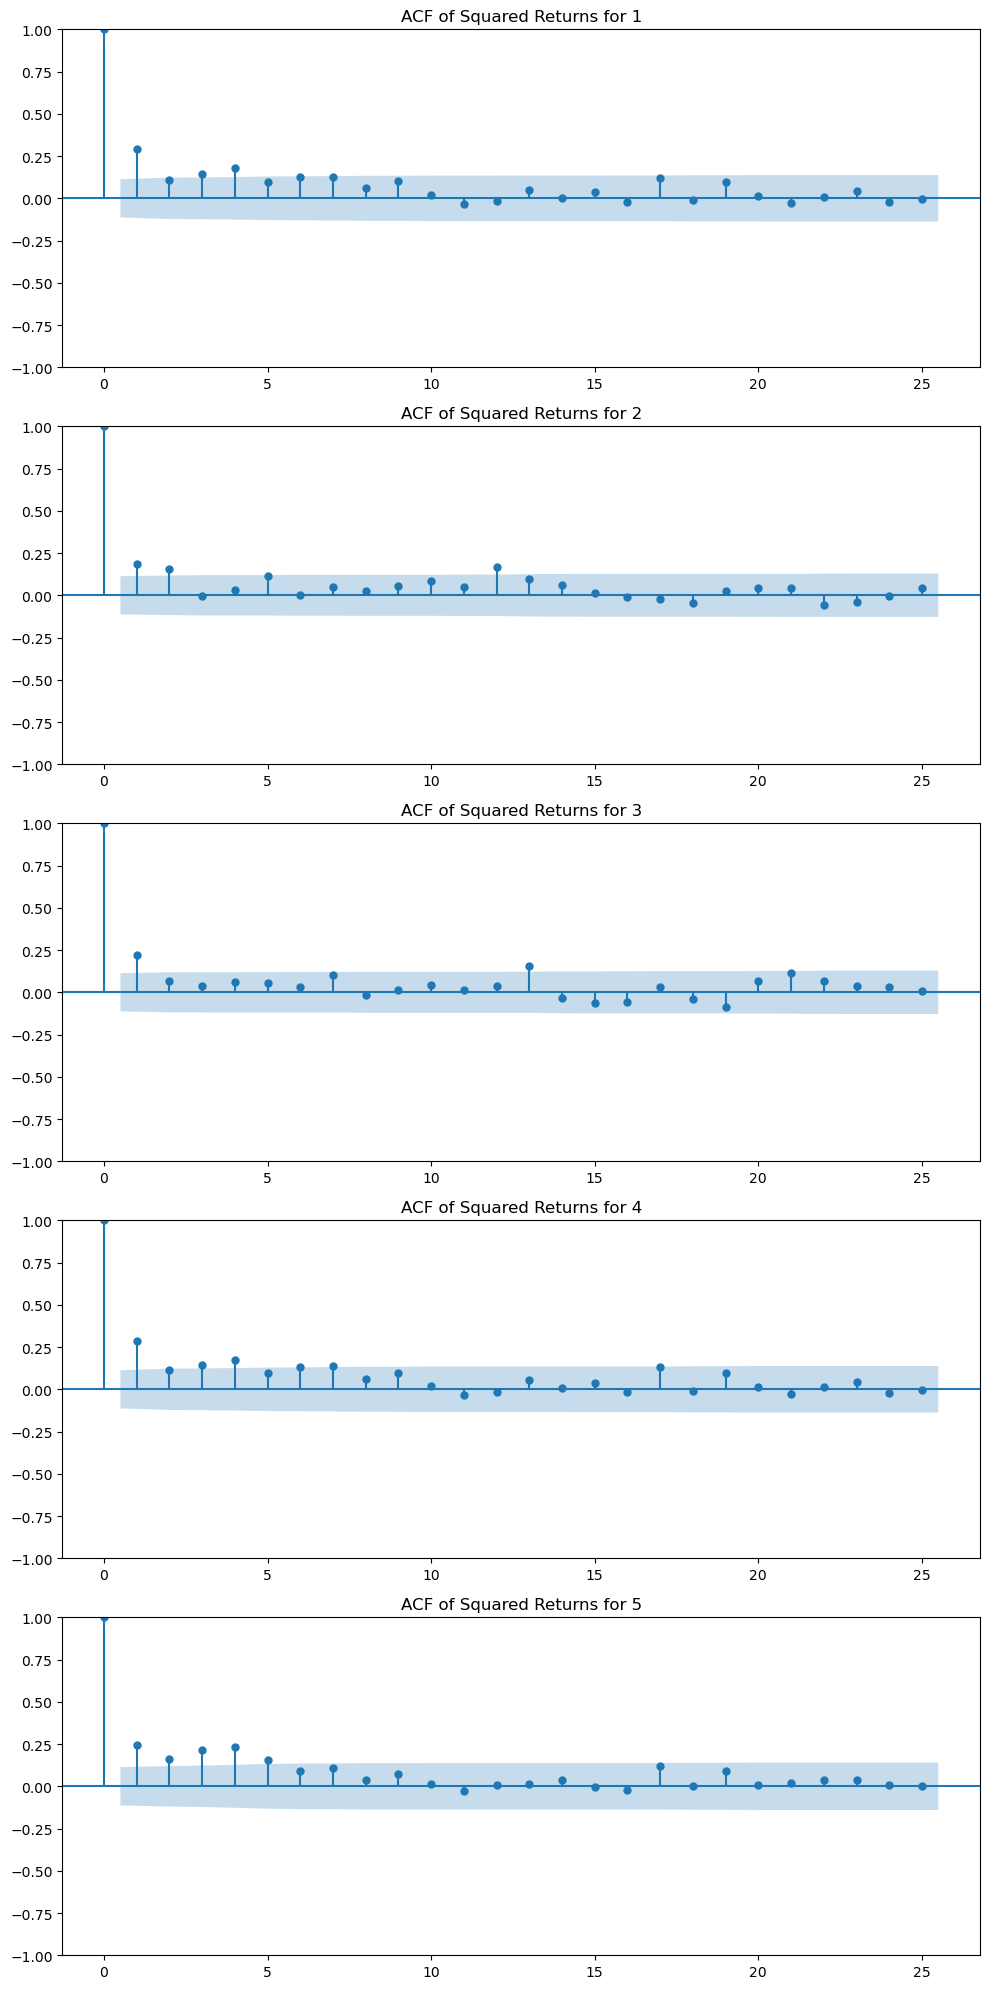

In [9]:
# plot acf and pacf for returns
fig, axes = plt.subplots(5, 2, figsize=(15, 20))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col], ax=axes[i, 0], title=f'ACF for {col}')
    plot_pacf(returns[col], ax=axes[i, 1], title=f'PACF for {col}')
plt.tight_layout()
plt.show()

# plot acf for squared returns (volatility clustering)
fig, axes = plt.subplots(5, 1, figsize=(10, 20))
for i, col in enumerate(returns.columns):
    plot_acf(returns[col]**2, ax=axes[i], title=f'ACF of Squared Returns for {col}')
plt.tight_layout()
plt.show()

## 6. Correlation Matrix

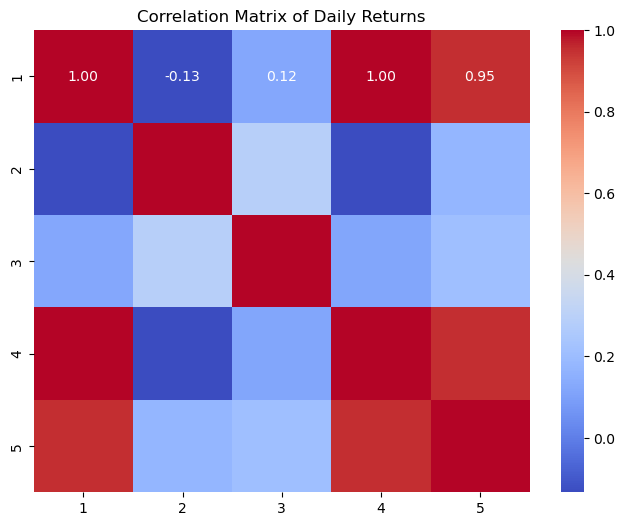

,1,2,3,4,5
1,1.000000,-0.133055,0.119434,0.999812,0.952145
2,-0.133055,1.000000,0.291278,-0.132708,0.175432
3,0.119434,0.291278,1.000000,0.118462,0.208866
4,0.999812,-0.132708,0.118462,1.000000,0.951665
5,0.952145,0.175432,0.208866,0.951665,1.000000


In [ ]:
# calculate correlation matrix
correlation_matrix = returns.corr()

# plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of monthly Returns')
plt.show()

correlation_matrix

## Tail Dependence

c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

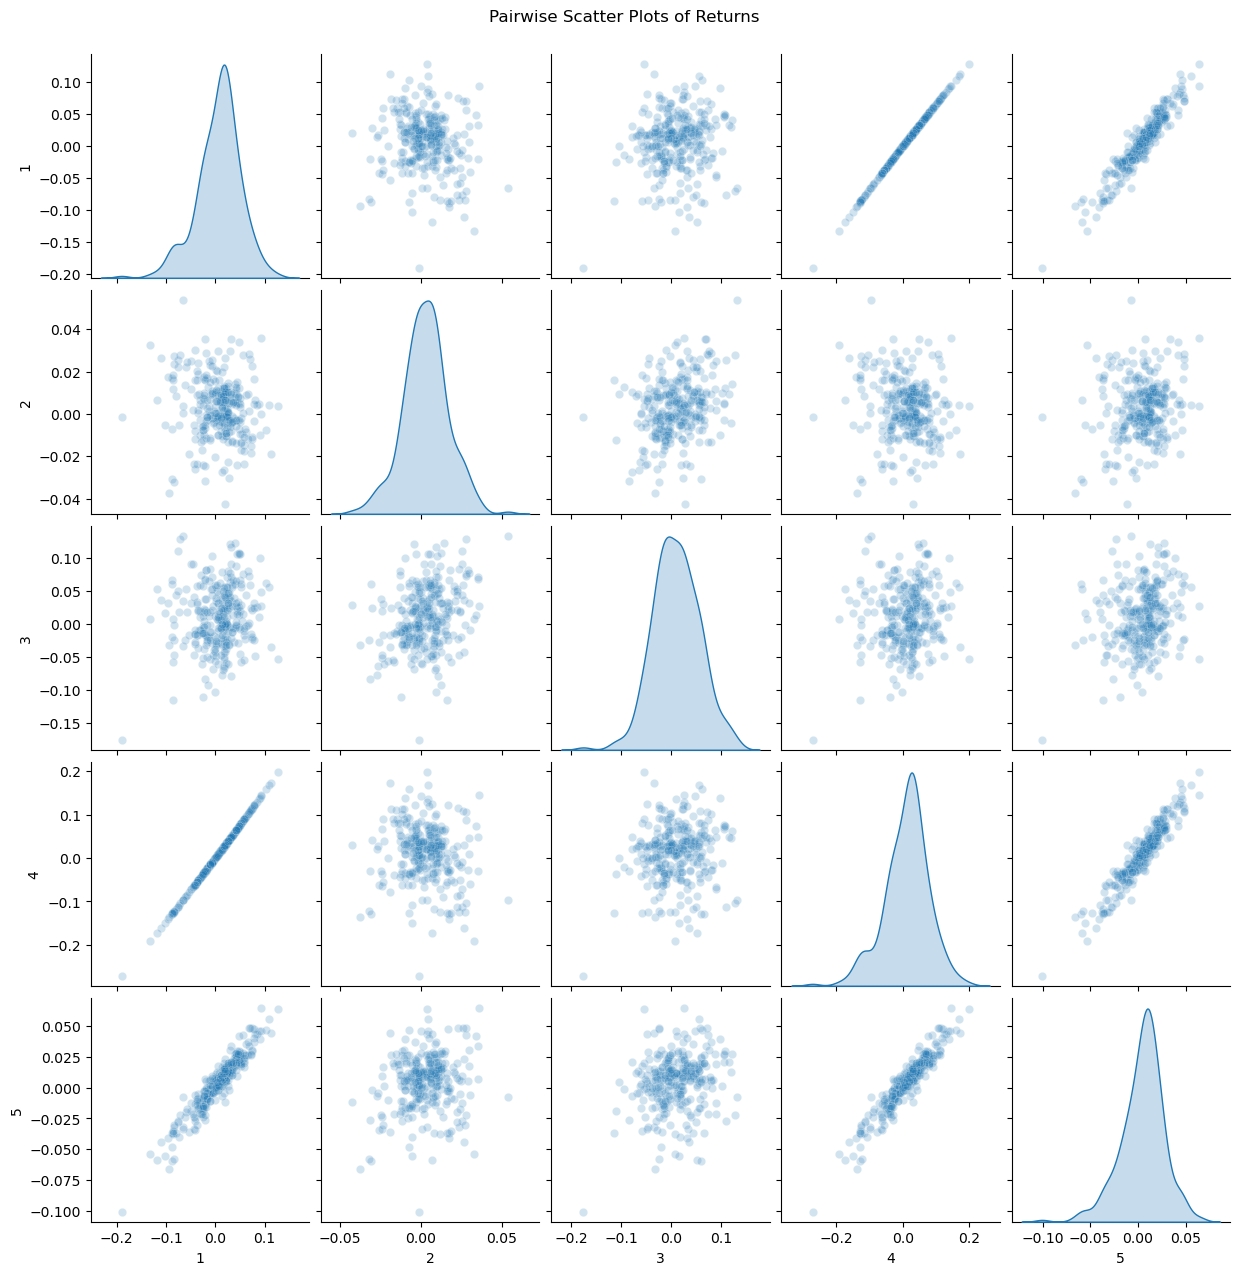

In [12]:
sns.pairplot(returns, diag_kind='kde', plot_kws={'alpha': 0.2})
plt.suptitle('Pairwise Scatter Plots of Returns', y=1.02)
plt.show()

c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
c:\Users\janne\anaconda3_new\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN 

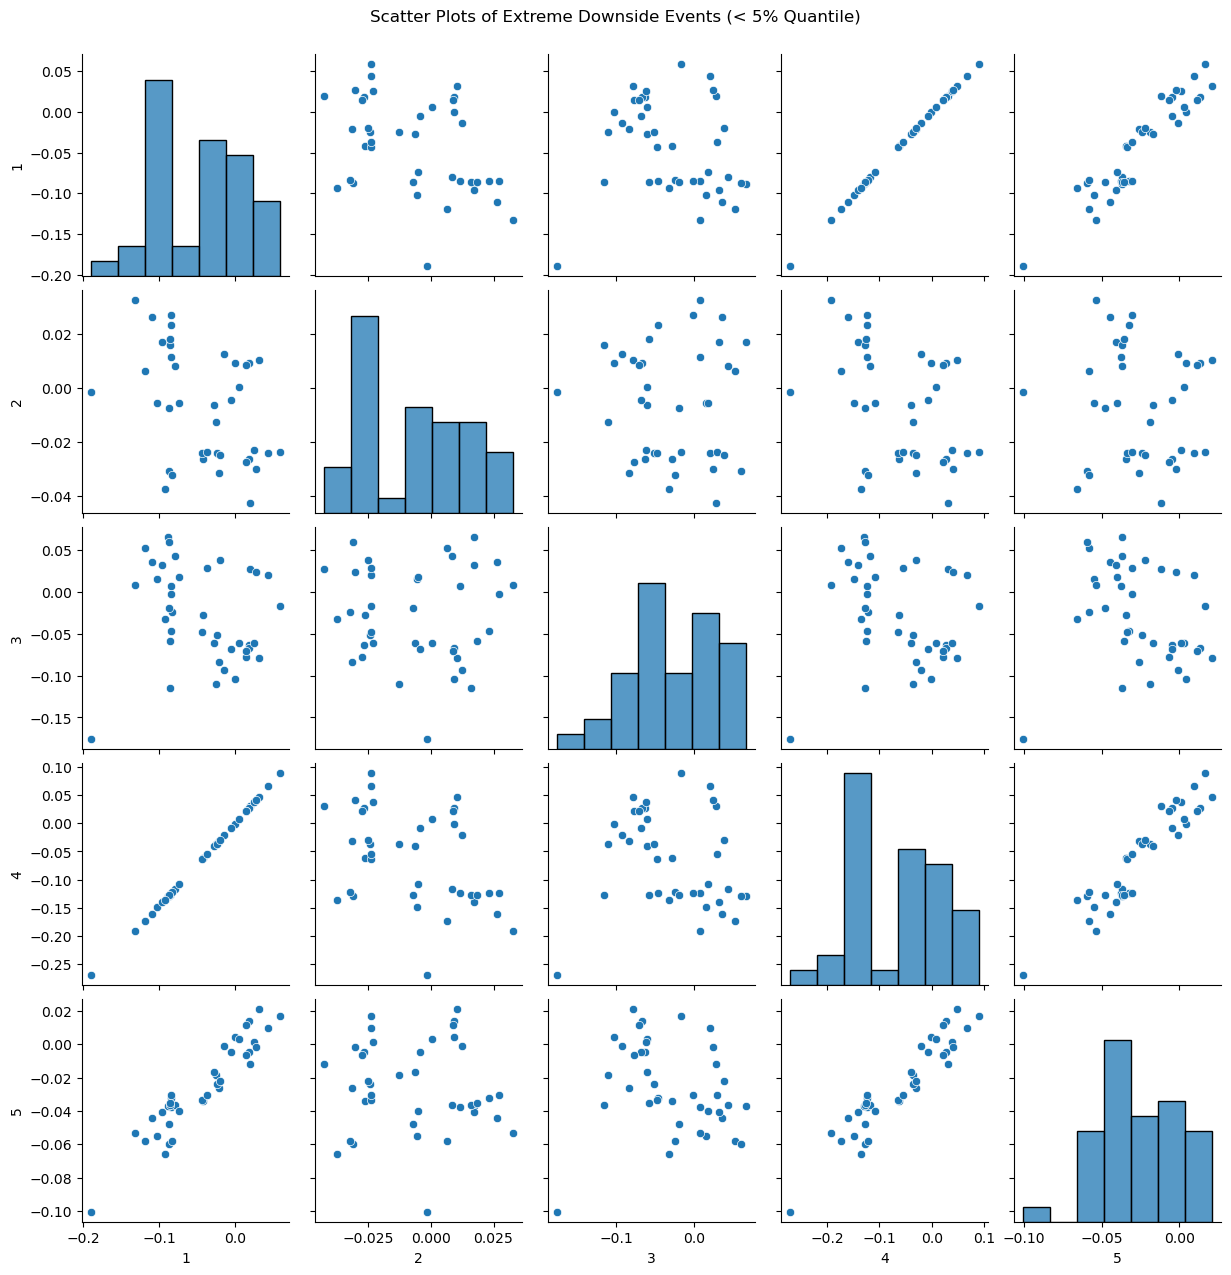

In [13]:
thresholds = returns.quantile(0.05)
tail_events = returns[(returns < thresholds).any(axis=1)]

sns.pairplot(tail_events)
plt.suptitle('Scatter Plots of Extreme Downside Events (< 5% Quantile)', y=1.02)
plt.show()

In [11]:
# check tail dependence with seaborn scatter plots
sns.pairplot(returns.quantile(0.05))
plt.suptitle('Scatter Plots of 5% Quantiles', y=1.02)
plt.show()

sns.pairplot(returns.quantile(0.95))
plt.suptitle('Scatter Plots of 95% Quantiles', y=1.02)
plt.show()

TypeError: 'data' must be pandas DataFrame object, not: <class 'pandas.core.series.Series'>